# Data Preparation — S2W8A2 Stage 2

WILDA Team 4 — Customer Churn Analysis.

Produces the Data Preparation deliverables:

1. A preprocessed dataset with missing values handled and categorical variables encoded
2. Training and testing sets for model validation, documented in `README.md`
3. Scaling applied to normalise the data, documented in `scaling_techniques.pdf`

The work itself lives in [`data_preparation.py`](data_preparation.py); this notebook
imports that script and runs it, so the notebook and the command line produce
byte-identical files and there is only one implementation to maintain. Run the same
pipeline without Jupyter with:

```bash
python Data_Preparation/data_preparation.py
```

**Before running:** place the team's raw dataset at `data/Dataset_ATS_v2.csv`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Works whether the notebook is started from the repository root or from
# Data_Preparation/, so the import below always resolves.
HERE = Path.cwd() if Path.cwd().name == "Data_Preparation" else Path.cwd() / "Data_Preparation"
sys.path.insert(0, str(HERE))

from data_preparation import (INPUT_PATH, OUT_DIR, RANDOM_STATE, SCALE_COLS,
                              TARGET_COL, TEST_SIZE, run_pipeline)

print(f"Raw dataset:   {INPUT_PATH}")
print(f"Output folder: {OUT_DIR}")
print(f"Target: {TARGET_COL} | test size: {TEST_SIZE} | random_state: {RANDOM_STATE}")
print(f"Columns scaled: {SCALE_COLS}")

Raw dataset:   C:\py\ACS\wilda-team4-customer-churn\data\Dataset_ATS_v2.csv
Output folder: C:\py\ACS\wilda-team4-customer-churn\Data_Preparation
Target: Churn | test size: 0.2 | random_state: 42
Columns scaled: ['tenure', 'MonthlyCharges']


## 1. Run the pipeline

One call runs every step in order: load, integrity checks, missing data, encoding,
save the preprocessed dataset, stratified split, scaling, then write the outputs.
The log below is what each step did.

In [2]:
preprocessed, train, test, scaler, encoders = run_pipeline()

Loaded dataset: 7043 rows, 10 columns
Columns: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn']

--- Data Integrity Check ---
Found 302 identical rows, KEPT: no customer ID, so identical profiles are treated as different customers.
Stripped whitespace from text columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'Churn']
SeniorCitizen check: all values are 0 or 1.
'tenure' check: no negative values.
'MonthlyCharges' check: no negative values.
Shape after integrity checks: (7043, 10)

--- Missing Data Handling ---
Missing values found: 0
Remaining missing values: 0

--- Categorical Encoding ---
Target 'Churn' encoded as: {'No': 0, 'Yes': 1}
Label-encoded binary columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService']
One-hot encoded 'Contract' (Month-to-month = baseline): Contract_One_year, Contract_Two_year
Shape after 

Saved scaling figure to: Data_Preparation\figures\scaling_before_after.png

=== Data Preparation Complete ===
Full dataset:   7043 rows, churn rate 26.54% (1869 churners)
Training set:   5634 rows, churn rate 26.54% (1495 churners)
Testing set:    1409 rows, churn rate 26.54% (374 churners)
Scaler (fitted on training data only):
  tenure: mean 32.3603, std 24.5639
  MonthlyCharges: mean 64.5351, std 30.2583


## 2. Integrity and missing data

Two checks worth calling out in the video. The dataset has **no missing values**, so the
median/mode imputation in the script never fires — it stays in the pipeline so a future
refresh of the data is handled rather than crashing.

The 302 identical rows are **kept**. There is no customer ID and only ten fairly coarse
columns, so two different customers on the same plan, with the same tenure and the same
monthly charge, produce an identical row. Dropping them would discard real customers and
shift the churn rate.

In [3]:
raw = pd.read_csv(INPUT_PATH)

print(f"Raw shape:            {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Missing values:       {int(raw.isna().sum().sum())}")
print(f"Identical rows:       {int(raw.duplicated().sum())} (kept)")
print(f"Rows carried through: {len(preprocessed):,}")

Raw shape:            7,043 rows x 10 columns
Missing values:       0
Identical rows:       302 (kept)
Rows carried through: 7,043


## 3. Encode categorical variables

Two encodings, chosen per column:

- **Label encoding** for the five two-value columns (`gender`, `Dependents`, `PhoneService`,
  `MultipleLines`, `InternetService`). A binary column maps to 0/1 with no ordering implied,
  and it keeps the feature readable. `SeniorCitizen` already arrives as 0/1.
- **One-hot encoding with `drop_first=True`** for `Contract`, which has three levels.
  Numbering them 0/1/2 would tell the model that a two year contract is "twice" a one year
  one; one-hot avoids that, and dropping the first level avoids the dummy-variable trap
  (perfect collinearity between the generated columns). Month-to-month is the baseline:
  both generated columns set to 0.

Every encoded column is cast to `int`, so there are no `True`/`False` values mixed in with
the 0/1s. The full mapping is saved to `encoding_map.json`.

In [4]:
for column, mapping in encoders.items():
    print(f"{column:<18} {mapping}")

preprocessed.head()

Churn              {'No': 0, 'Yes': 1}
gender             {'Female': 0, 'Male': 1}
Dependents         {'No': 0, 'Yes': 1}
PhoneService       {'No': 0, 'Yes': 1}
MultipleLines      {'No': 0, 'Yes': 1}
InternetService    {'DSL': 0, 'Fiber optic': 1}
Contract           {'Month-to-month': 'baseline (both 0)', 'One year': 'Contract_One_year=1', 'Two year': 'Contract_Two_year=1'}


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Contract_One_year,Contract_Two_year,Churn
0,0,0,0,1,0,0,0,25,0,0,1
1,1,0,0,41,1,0,0,25,1,0,0
2,0,0,1,52,1,0,0,19,0,0,0
3,0,0,0,1,1,0,0,76,1,0,1
4,1,0,0,67,1,0,1,51,0,0,0


## 4. Train / test split

Stratified on the target so both sets keep the same churn rate — important when churn is
the minority class at 26.54%. `random_state=42` makes the split reproducible.

This table is the "size and composition" documentation the assignment asks for; the fuller
version, including the contract mix, is in [`README.md`](README.md).

In [5]:
composition = pd.DataFrame({
    "rows": [len(preprocessed), len(train), len(test)],
    "% of total": [100.0,
                   round(100 * len(train) / len(preprocessed), 2),
                   round(100 * len(test) / len(preprocessed), 2)],
    "churners": [int(preprocessed[TARGET_COL].sum()),
                 int(train[TARGET_COL].sum()),
                 int(test[TARGET_COL].sum())],
    "churn rate": [f"{preprocessed[TARGET_COL].mean():.2%}",
                   f"{train[TARGET_COL].mean():.2%}",
                   f"{test[TARGET_COL].mean():.2%}"],
}, index=["full dataset", "training set", "test set"])

composition

,rows,% of total,churners,churn rate
full dataset,7043,100.00,1869,26.54%
training set,5634,79.99,1495,26.54%
test set,1409,20.01,374,26.54%


## 5. Scaling

`StandardScaler` centres a feature at zero with unit variance: `z = (x - mean) / std`.
Only `tenure` (0–72 months) and `MonthlyCharges` ($18–$119) are scaled — the other eight
features are already 0/1 flags, and the target is never scaled.

**The scaler is fitted on the training set only**, then applied to the test set. Fitting on
the full dataset would leak information about the test set into training and inflate the
results.

The check below is the evidence: the training columns come out at exactly mean 0 and
standard deviation 1, while the test columns land close to but deliberately *not* exactly
on 0 and 1. If the test columns were also exact, the scaler would have seen them.

In [6]:
stats = pd.DataFrame({
    "fitted mean (train)": scaler.mean_,
    "fitted std (train)": scaler.scale_,
    "train mean after": train[SCALE_COLS].mean().values,
    "train std after": train[SCALE_COLS].std(ddof=0).values,
    "test mean after": test[SCALE_COLS].mean().values,
    "test std after": test[SCALE_COLS].std(ddof=0).values,
}, index=SCALE_COLS).round(4)

stats

,fitted mean (train),fitted std (train),train mean after,train std after,test mean after,test std after
tenure,32.3603,24.5639,0.0,1.0,0.0022,0.9987
MonthlyCharges,64.5351,30.2583,0.0,1.0,0.0369,0.9712


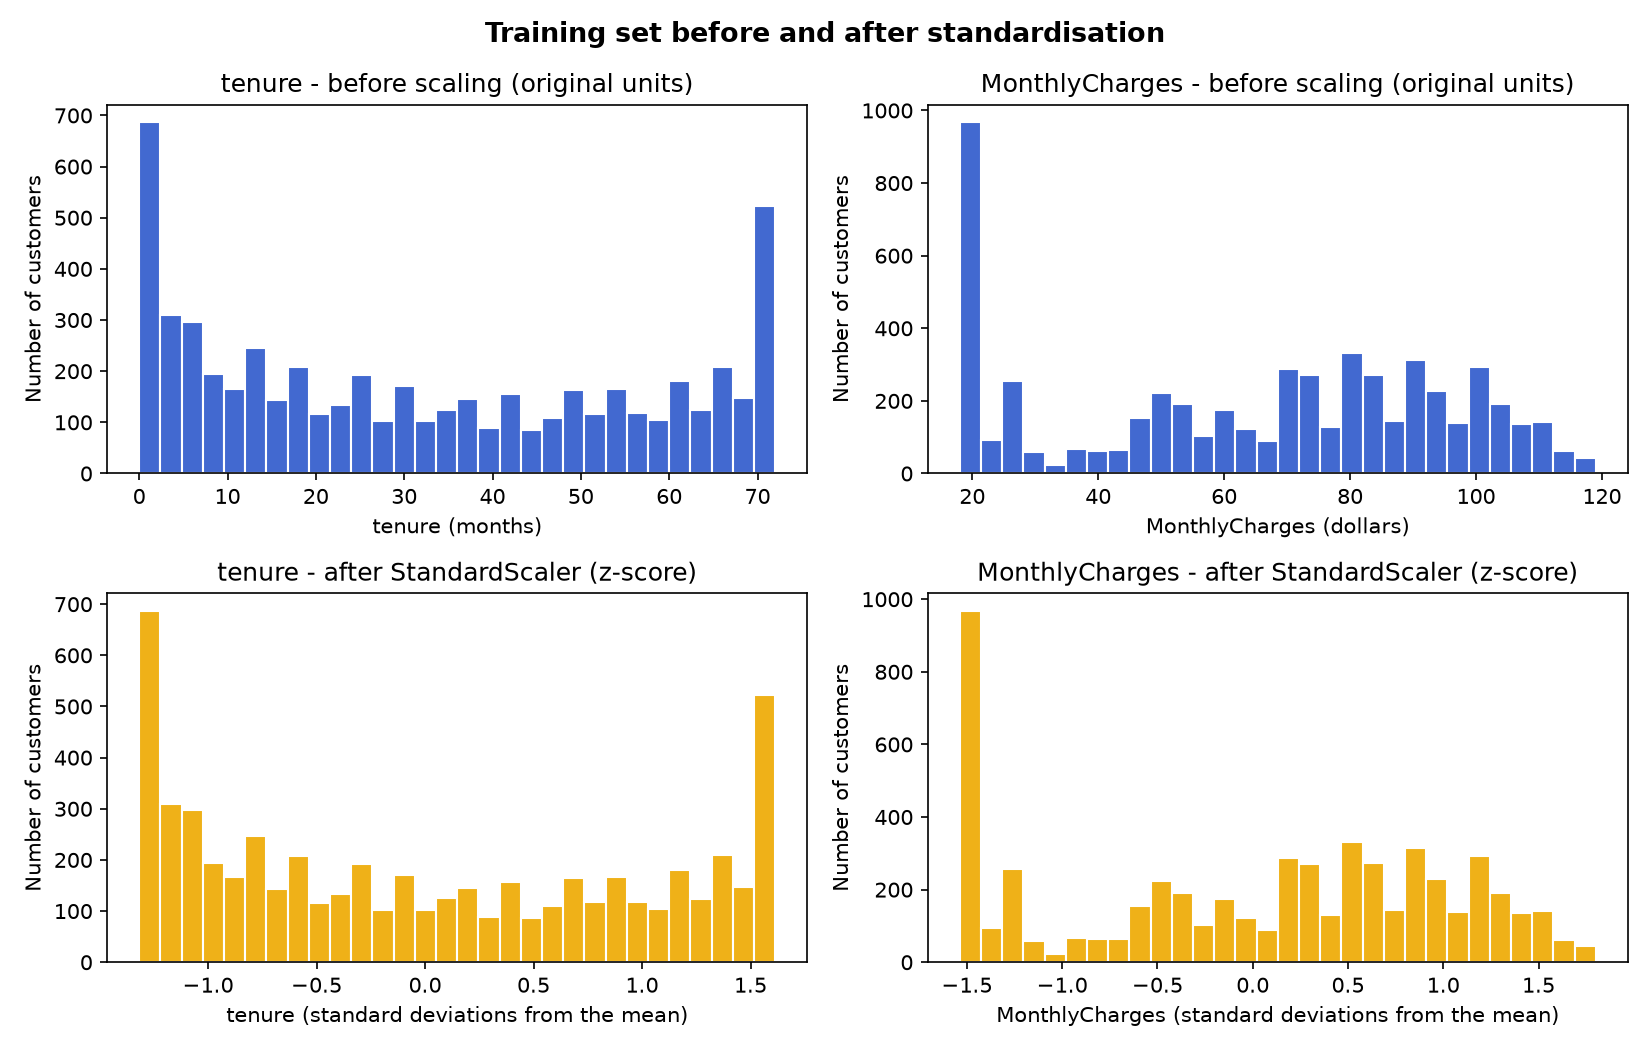

In [7]:
display(Image(filename=str(OUT_DIR / "figures" / "scaling_before_after.png"), width=900))

## 6. Deliverables written

Every file below is written by the run above. The two documents — `README.md` and
`scaling_techniques.pdf` — are generated from `preparation_summary.json` by
[`build_docs.py`](build_docs.py), so no number in them is typed by hand:

```bash
python Data_Preparation/build_docs.py
```

In [8]:
for name in ["preprocessed_dataset.csv", "train_set.csv", "test_set.csv", "scaler.pkl",
             "encoding_map.json", "preparation_summary.json", "README.md",
             "scaling_techniques.pdf", "figures/scaling_before_after.png"]:
    path = OUT_DIR / name
    size = f"{path.stat().st_size / 1024:,.1f} KB" if path.exists() else "MISSING"
    print(f"{name:<38} {size}")

preprocessed_dataset.csv               171.2 KB
train_set.csv                          319.0 KB
test_set.csv                           79.9 KB
scaler.pkl                             0.9 KB
encoding_map.json                      0.5 KB
preparation_summary.json               2.2 KB
README.md                              6.0 KB
scaling_techniques.pdf                 148.9 KB
figures/scaling_before_after.png       111.0 KB
